### Load Data

In [3]:
from typing import Any
import re
from collections import defaultdict

def parse_iou_data(text: str):
    sparsity_pattern: re.Pattern[str] = re.compile(pattern=r"sparsity\s+([0-9.]+)")
    row_pattern: re.Pattern[str] = re.compile(pattern=r"\|\s*(.*?)\s*\|\s*([0-9.]+)\s*\|\s*([0-9.]+)\s*\|")

    data = defaultdict(dict)
    current_sparsity = None

    for line in text.splitlines():
        # detect sparsity
        s_match: re.Match[str] | None = sparsity_pattern.search(string=line)
        if s_match:
            current_sparsity = float(s_match.group(1))
            continue

        # detect table rows
        r_match: re.Match[str] | None = row_pattern.search(string=line)
        if r_match and current_sparsity is not None:
            cls: str | Any = r_match.group(1).strip()
            iou = float(r_match.group(2))

            # skip header
            if cls.lower() == "class":
                continue

            data[cls][current_sparsity] = iou

    return dict(data)

In [7]:
with open(file="val-results/results-mas2former-baseline-seed7-acdc-night.txt", mode="r") as f:
    text_seed7: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed25-acdc-night.txt", mode="r") as f:
    text_seed_25: str = f.read()

with open(file="val-results/results-mas2former-baseline-seed42-acdc-night.txt", mode="r") as f:
    text_seed42: str = f.read()



data_seed7 = parse_iou_data(text_seed7)
data_seed25 = parse_iou_data(text_seed_25)
data_seed42 = parse_iou_data(text_seed42)

print(data_seed7["road"])
print(data_seed25["road"])
print(data_seed42["road"])

{0.0: 79.31, 0.4: 82.65, 0.5: 70.85, 0.6: 79.79, 0.7: 70.54, 0.8: 73.48, 0.9: 55.08}
{0.4: 76.9, 0.5: 83.75, 0.6: 79.66, 0.7: 79.24, 0.8: 81.48, 0.9: 72.09}
{0.0: 75.73, 0.4: 81.18, 0.5: 78.06, 0.6: 86.14, 0.7: 87.82, 0.8: 70.57, 0.9: 68.5}


### Create plots per seed

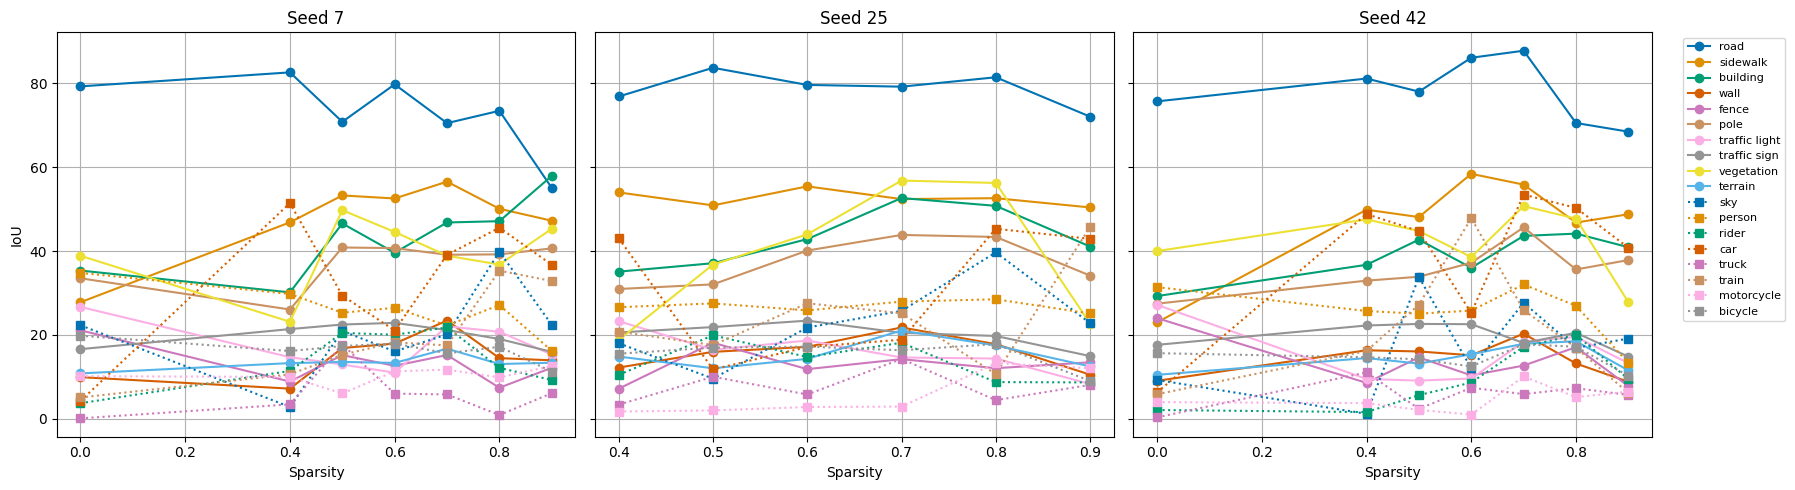

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [data_seed7, data_seed25, data_seed42]
titles = ["Seed 7", "Seed 25", "Seed 42"]

classes = list(datasets[0].keys())

colors = sns.color_palette("colorblind", 10)

for ax, data, title in zip(axes, datasets, titles):
    sparsities = sorted({s for cls in data.values() for s in cls})

    for i, cls in enumerate(classes):
        y = [data[cls].get(s, None) for s in sparsities]

        if i < 10:
            linestyle = '-'
            marker = 'o'
        else:
            linestyle = ':'
            marker = 's'

        ax.plot(sparsities, y,
                marker=marker,
                label=cls,
                color=colors[i % 10],
                linestyle=linestyle)

    ax.set_title(title)
    ax.set_xlabel("Sparsity")
    ax.grid(True)

axes[0].set_ylabel("IoU")

handles, labels = axes[0].get_legend_handles_labels()

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

datasets = [data_seed7, data_seed25, data_seed42]
classes = list(datasets[0].keys())

# collect all sparsities
sparsities = sorted({s for d in datasets for cls in d.values() for s in cls})

mean_data = {}
std_data = {}

for cls in classes:
    mean_vals = []
    std_vals = []

    for s in sparsities:
        vals = [d[cls][s] for d in datasets if s in d[cls]]

        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals, ddof=1))  # <-- n-1

    mean_data[cls] = mean_vals
    std_data[cls] = std_vals

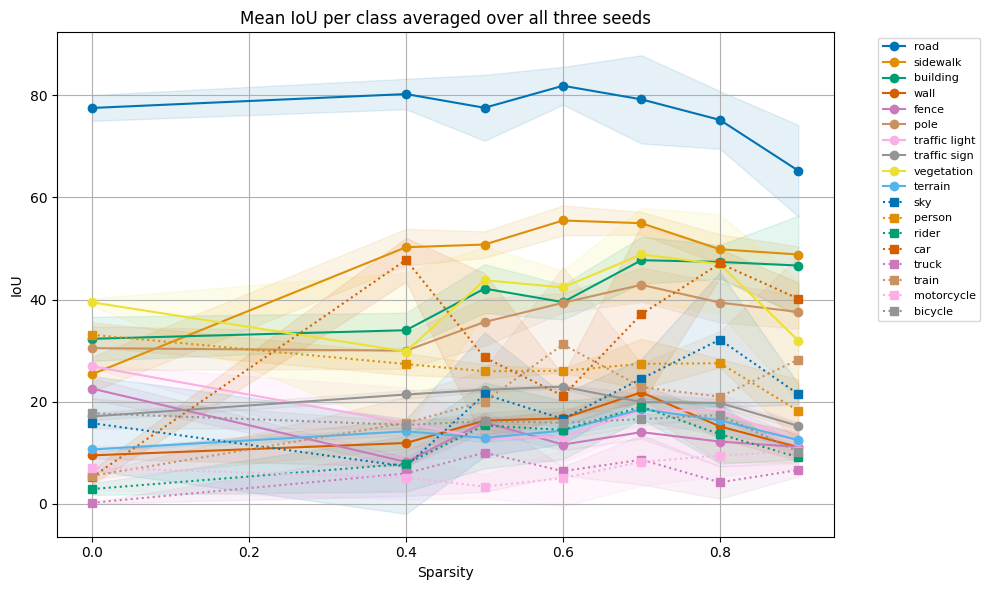

In [14]:
colors = sns.color_palette("colorblind", len(classes))

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    y = mean_data[cls]
    y_std = std_data[cls]

    if i < 10:
        linestyle = '-'
        marker = 'o'
 
    else:
        linestyle = ':'
        marker = 's'

    plt.plot(sparsities, y,
             label=cls,
             color=colors[i % 10],
             marker=marker,
             linestyle=linestyle)

    # shaded std
    plt.fill_between(
        sparsities,
        np.array(y) - np.array(y_std),
        np.array(y) + np.array(y_std),
        color=colors[i % 10],
        alpha=0.1
    )

plt.xlabel("Sparsity")
plt.ylabel("IoU")
plt.title("Mean IoU per class averaged over all three seeds")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()